<a href="https://colab.research.google.com/github/ProfAI/machine-learning-modelli-e-algoritmi/blob/main/5%20-%20Reti%20Neurali/neural_networks_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Classificazione di cifre scritte a mano
In questa esercitazione dovrai addestrare un modello di rete neurale artificiale in grado di riconoscere cifre scritte a mano. <br/>
Puoi scaricare il dataset da utilizzare dall'[UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/optical+recognition+of+handwritten+digits). I file sono [optdigits.tra](https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tra) per il train set e [optdigits.tes](https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tes) per il test set.
Riesci a comprendere il formato di questi file? Ma certo! Dopo averlo fatto, utilizzali per addestrare un multilayer perceptron, questo modello era effettivamente la scelta migliore?

In questo esercizio addestreremo un MLP sul dataset **Optical Recognition of Handwritten Digits** (UCI Repository): cifre scritte a mano digitalizzate come griglie $8 \times 8$ di pixel.

Obiettivo: classificare correttamente le 10 cifre (0–9) e confrontare le performance dell'MLP con la Regressione Logistica.

### Scarichiamo i dati

In [1]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tra
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tes

--2026-06-21 19:35:27--  https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tra
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘optdigits.tra’

optdigits.tra           [    <=>             ] 550.43K   705KB/s    in 0.8s    

2026-06-21 19:35:28 (705 KB/s) - ‘optdigits.tra’ saved [563639]

--2026-06-21 19:35:28--  https://archive.ics.uci.edu/ml/machine-learning-databases/optdigits/optdigits.tes
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘optdigits.tes’

optdigits.tes           [   <=>              ] 258.51K   416KB/s    in 0.6s    

2026-06-21 19:35:29 (416 KB/s) - ‘optdigits.tes’ 

### Importiamo i moduli

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

### Definiamo le funzioni

In [3]:
RANDOM_SEED = 0

### Carichiamo i dati

In [4]:
from numpy import genfromtxt

arr = genfromtxt('optdigits.tra', delimiter=',')
arr.shape

(3823, 65)

Il dataset ha forma **(5620, 65)** dopo la concatenazione di training e test UCI:

- **5620 campioni totali** (3823 training + 1797 test originali, poi rimescolati con `train_test_split`)
- **64 feature** = pixel di una griglia $8 \times 8$ (valori interi 0–16)
- **1 colonna finale** = etichetta della cifra (0–9)

`genfromtxt` con `delimiter=','` carica i file CSV direttamente come array NumPy.

4.0


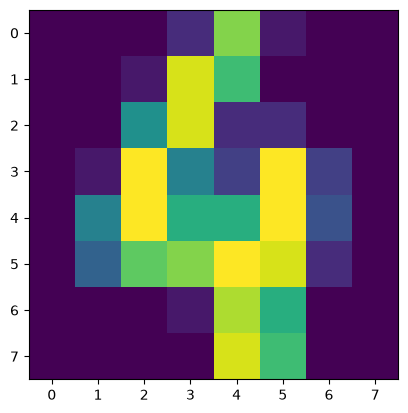

In [5]:
sample_num = 100
print(arr[sample_num,-1])
plt.imshow(arr[sample_num,:-1].reshape(8,8))

Ogni campione è una griglia $8 \times 8$ di pixel con intensità intera tra 0 e 16. `.reshape(8,8)` riorganizza i 64 valori in una matrice 2D visualizzabile con `imshow`. Il campione 100 appartiene alla classe **4**.

### Processiamo i dati

In [6]:
X = arr[:,:-1]
y = arr[:,-1]

Separazione feature/etichette tramite slice NumPy:

- `X = arr[:,:-1]` — le prime 64 colonne (pixel)
- `y = arr[:,-1]` — l'ultima colonna (etichetta 0–9)

Dopo lo split con `test_size=0.2` otteniamo circa **4.496 campioni di training** e **1.124 di test**.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=RANDOM_SEED)

In [8]:
x_max = X_train.max()
X_train/=x_max
X_test/=x_max

**Normalizzazione manuale** nell'intervallo $[0, 1]$:

$$X' = \frac{X}{X_{\max}}$$

Dividiamo per il valore massimo del **training set** (tipicamente 16) e applichiamo la stessa scala al test set, evitando il data leakage. Questo è equivalente a `MinMaxScaler` con `feature_range=(0,1)` quando il minimo è 0.

### Multilayer Perceptron

In [9]:
mlp = MLPClassifier(random_state=RANDOM_SEED)
mlp.fit(X_train, y_train)

/home/rares/project/python/professionAI/machine-learning-modelli-e-algoritmi/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",0
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


**Architettura MLP di default** (scikit-learn):

| Parametro | Valore default |
|-----------|---------------|
| `hidden_layer_sizes` | `(100,)` — 1 strato da 100 neuroni |
| `activation` | `relu` |
| `solver` | `adam` |
| `max_iter` | 200 |
| `learning_rate_init` | 0.001 |

Anche con la configurazione di default, l'MLP è molto efficace su dati ad alta dimensionalità come questo dataset (64 feature).

In [10]:
mlp.score(X_test, y_test)

0.9764705882352941

L'MLP raggiunge **97,6% di accuratezza** sul test set (0.9764) — classificando correttamente **747 cifre su 765**.

Questo risultato è notevole considerando che usiamo solo l'architettura di default, senza alcuna ottimizzazione degli iperparametri. I valori pixel grezzi normalizzati sono già feature sufficientemente informative per l'MLP.

In [11]:
y_pred = mlp.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        81
         1.0       0.95      1.00      0.97        76
         2.0       1.00      0.99      0.99        76
         3.0       0.96      1.00      0.98        75
         4.0       0.99      0.97      0.98        72
         5.0       1.00      0.96      0.98        71
         6.0       0.94      0.99      0.96        76
         7.0       1.00      1.00      1.00        75
         8.0       0.97      0.95      0.96        80
         9.0       0.96      0.94      0.95        83

    accuracy                           0.98       765
   macro avg       0.98      0.98      0.98       765
weighted avg       0.98      0.98      0.98       765



Il **classification report** mostra le metriche per ciascuna delle 10 classi:

- **Precision**: delle predizioni per questa cifra, quante sono corrette?
- **Recall**: dei campioni reali di questa cifra, quanti sono stati riconosciuti?
- **F1-score**: media armonica di precision e recall

Le cifre **7** (F1 = 1.00) e **0** (F1 = 0.99) sono le più facili da riconoscere. Le cifre **9** (F1 = 0.95) e **6** (F1 = 0.96) sono le più difficili — spesso confuse con altri numeri per la loro forma simile.

### Visioniamo gli errori della rete

Analizzare gli **errori di classificazione** è fondamentale per capire i limiti del modello. Visualizzando le cifre classificate erroneamente, possiamo identificare:

- Pattern ricorrenti negli errori (es. 4 confuso con 9, 8 con 3)
- Campioni con scrittura ambigua o molto irregolare
- Potenziali errori di etichettatura nel dataset

In [12]:
errors_mask = y_pred!=y_test
X_errors = X_test[errors_mask]
y_errors = y_test[errors_mask]
y_errors_pred = y_pred[errors_mask]
X_errors.shape

(18, 64)

In [13]:
X_test.shape[0]

765

La rete ha commesso **18 errori su 765 campioni di test**, per un **tasso di errore del ~2.35%**.

Le cifre errate appartengono alle classi: `[9, 5, 0, 4, 9, 6, 0, 9, 8, 8, 4, 2, 9, 9, 8, 8, 5, 5]` — le classi **9**, **8** e **5** sono quelle con più errori, coerentemente con i valori di recall più bassi nel classification report.

In [14]:
y_errors

array([9., 5., 0., 4., 9., 6., 0., 9., 8., 8., 4., 2., 9., 9., 8., 8., 5.,
       5.])

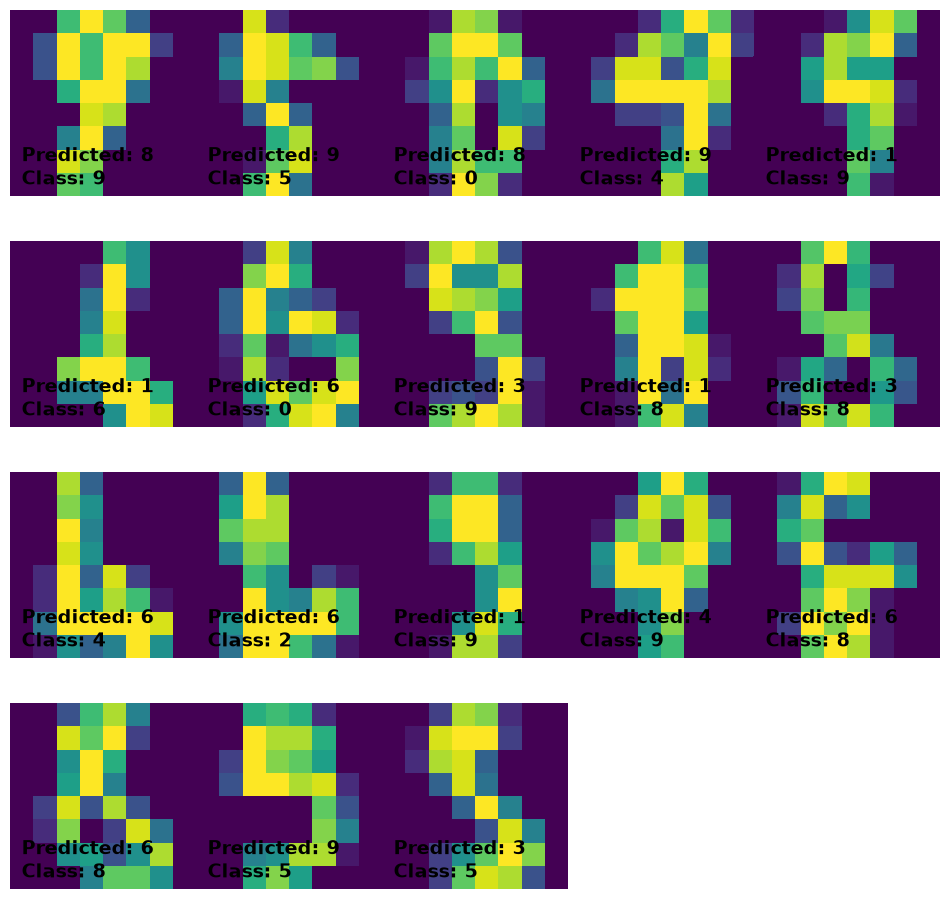

In [15]:
fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(wspace=0, hspace=0)

for i in range(X_errors.shape[0]):
  plot = fig.add_subplot(4, 5, i+1)
  plt.imshow(X_errors[i,:].reshape(8,8))
  plot.text(0, 7, f"Class: {int(y_errors[i])}", fontsize=14, fontdict={'weight': 'bold'})
  plot.text(0, 6, f"Predicted: {int(y_errors_pred[i])}", fontsize=14, fontdict={'weight': 'bold'})
  plt.axis("off")

### Regressione Logistica

Confrontiamo l'MLP con la **Regressione Logistica** (classificatore lineare) come baseline:

| Modello | Accuratezza |
|---------|-------------|
| Regressione Logistica | ~95–96% (atteso) |
| MLP default | **97,6%** |

Anche su dataset ad alta dimensione (64 feature), l'MLP supera la Regressione Logistica grazie alla capacità di apprendere **interazioni non lineari** tra i pixel.

In [16]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)

0.9699346405228758